In [1]:
#PArt A
#task 1
import pandas as pd
import matplotlib.pyplot as plt
#importing the pandas library  and matplot

ratings = pd.read_csv('data/ratings.csv') #rating df
movies = pd.read_csv('data/movies.csv') #movies df
#reading the csv files and putting them into dataframes
ratings




,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [2]:
num_users = ratings['userId'].nunique() #how many cells are filled by info unique()
num_movies = ratings['movieId'].nunique()
num_ratings = len(ratings)

total_possible_cells = num_users * num_movies#total number of possible rating
sparsity = 1.0 - (num_ratings / total_possible_cells) #describe how empty is our matrix

print(f"Users: {num_users}, Movies: {num_movies}, Ratings: {num_ratings}")
print(f"Matrix Sparsity: {sparsity:.2%}")

Users: 610, Movies: 9724, Ratings: 100836
Matrix Sparsity: 98.30%


In [3]:
#task 13
test_df = ratings.groupby('userId').sample(frac=0.2, random_state=42) #this allows us to pick only 20% of rating for each user, random state mean we will get the same result every time
train_df = ratings.drop(test_df.index)#removes the 20% of test data from the list
test_df#tail and head only


,userId,movieId,rating,timestamp
219,1,3578,5.0,964980668
66,1,1127,4.0,964982513
9,1,157,5.0,964984100
170,1,2617,2.0,964982588
15,1,260,5.0,964981680
...,...,...,...,...
99701,610,2976,4.0,1479542190
99935,610,5956,3.5,1479542164
100011,610,7173,3.0,1493847204
100197,610,45722,3.5,1493844944


In [4]:
train_matrix = pd.pivot_table(
    train_df, 
    values='rating', 
    index='userId', 
    columns='movieId'
)
#making a 2d matrix form of the raw data from the data-
#frame given colomns with the movie ids and the rows with the user ids
train_matrix

movieId,1,2,3,4,5,6,7,8,9,10,...,191005,193565,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,2.5,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


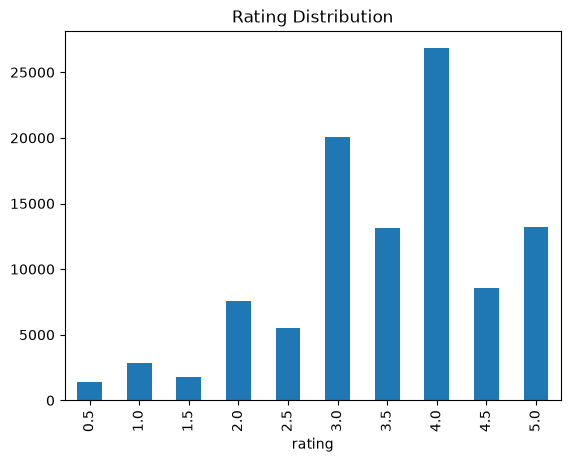

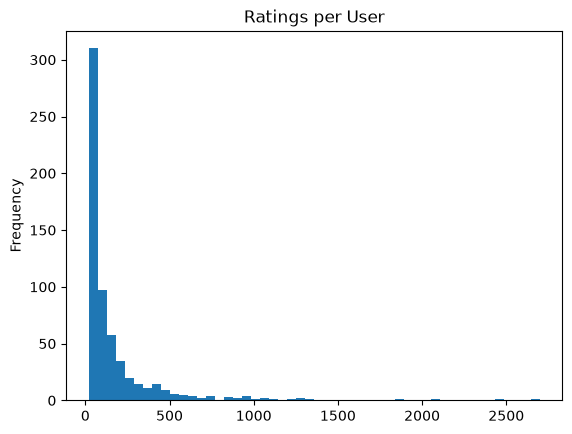

In [5]:
# 1. Distribution of rating values (e.g., how many 4.0s vs 1.0s)
ratings['rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
plt.show()
#rating['rating'] makes us work on the rating column only 
# #value counts counts how many times each score appeared and then we sort and plot
# 2. Distribution of how many ratings each user submitted
ratings.groupby('userId').size().plot(kind='hist', bins=50, title='Ratings per User')
plt.show()
#here we groupby we group each user alone and then we take the number of ratings that they recorded

In [ ]:
#Part B
#task 5
import numpy as np
#this is an important function that allows us to get 2 vectors of movie a and b and their rating data or 2 for user a and b and their rating data

def get_co_rated(matrix, a, b, axis='index'):    
    # Extract the raw vectors (rows for users, columns for items)
    if axis == 'index':
        vec_a = matrix.loc[a]
        vec_b = matrix.loc[b] #rows user a rating and user b rating every individual rating the peron a and person b made
    else:
        vec_a = matrix[a]
        vec_b = matrix[b]#colomns movie a and movie b every rating for the move a and b fromo different users
        b
    # Combine them into a temporary 2-column table and drop any row with a NaN
    temp_df = pd.DataFrame({'a': vec_a, 'b': vec_b}).dropna()#drops the nAn values so the program dont crash while comparing
    
    # Extract the clean columns back out as raw NumPy arrays
    return temp_df['a'].values, temp_df['b'].values



In [ ]:
#task 6
def euclidean_similarity(vec1, vec2):
    # Rule: If they share fewer than 2 movies, similarity is undefined
    if len(vec1) < 2: return np.nan 
    
    # Vectorized math replaces a for loop summing (vec1[i] - vec2[i])^2 
    distance = np.sqrt(np.sum((vec1 - vec2)**2))# this is the equation for it higher mean higher similarity
    return 1 / (1 + distance)

In [ ]:
#task 7
def cosine_similarity(vec1, vec2):
    if len(vec1) < 2: return np.nan
    
    numerator = np.dot(vec1, vec2)
    denominator = np.linalg.norm(vec1) * np.linalg.norm(vec2)
    #linlag sum of squares and taken the sqrt of them
    
    if denominator == 0: return 0.0
    return numerator / denominator #implementing the formula only

In [ ]:
#task 8
def pearson_similarity(vec1, vec2):
    if len(vec1) < 2: return np.nan
    
    # Mean-center the data to remove the "generous/harsh rater" bias[cite: 1]
    vec1_centered = vec1 - np.mean(vec1)
    vec2_centered = vec2 - np.mean(vec2)
    
    numerator = np.dot(vec1_centered, vec2_centered)
    denominator = np.linalg.norm(vec1_centered) * np.linalg.norm(vec2_centered) #linlag.norm is the sum of squared values in the array and then we take the square root value for it
    
    if denominator == 0: return 0.0
    return numerator / denominator

In [ ]:
# sanity test
import numpy as np

# The exact "generous vs. harsh rater" arrays from the assignment[cite: 1]
user_a = np.array([5, 4, 5, 3])
user_b = np.array([3, 2, 3, 1])

print(f"Euclidean Similarity: {euclidean_similarity(user_a, user_b):.3f}")
print(f"Cosine Similarity: {cosine_similarity(user_a, user_b):.3f}")
print(f"Pearson Similarity: {pearson_similarity(user_a, user_b):.3f}")

Euclidean Similarity: 0.200
Cosine Similarity: 0.987
Pearson Similarity: 1.000


#so the euclidean similarity depends on the actual rating between the users so it fails to see the pattern between them its distance dependant the distance of user a and user b in this  example is 2 so it gives us a low value

#cosine similarity compares the angle of each vector but it fails to adjust for the constant offset so it is not a perfect 1.0

#pearson similarity gives us a perfect 1.0 because it focuses on the distance between the values and the mean for each value elimiting the constant shift so this is why the pearson similarity model is the best to use for the movie reccomendation system

In [ ]:
#Part C User based colloborative filtering
#task 9

def find_k_nearest_users(matrix,target_user,k,similarityfn):
    similarities=[]#the array we put the users and the similarity value that we get from the up functions
    for user in matrix.index: #rows
        if user == target_user: #prevents comparing the targeted user with himself
            continue
        vec_target, vec_other =get_co_rated(matrix, target_user, user,axis='index')
        #we just get their overlapping ratings in a matrix using the co rated function
        sim = similarityfn(vec_target,vec_other)
        if not np.isnan(sim):
            similarities.append((user, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)  #sortin the list of tuples (user,sim value) in a descending order according to the sim value

    return similarities[:k]


#this function loops in the whole matrix of users and gets us a list of users with a similar taste in movies to our targeted user
#key=lambda x: x[1] is the second value in the tuple 
#the k value is the top k values in the list of tuples (k nn)


In [ ]:
#task 10 predict the rating user based
#this function predicts  what the target user will rate a movie that he havent seen from knn 
def predict_rating_user_based(matrix, target_user, target_item, k, similarityfn):
    nearest_users = find_k_nearest_users(matrix, target_user, k, similarityfn)
    numerator = 0.0
    denominator = 0.0 
    for user, sim in nearest_users:
        rating = matrix.loc[user, target_item] #--takes the rating of a single movie from a single user
        
        # Only include neighbors who actually rated the target movie
        if not np.isnan(rating): # -- discards the neighbors who hadnt rated the movie
            numerator += sim * rating # -- adds the weight of the rating to the numerator
            
            denominator += np.abs(sim)#just scales rating to its normal value by dividing the similarity value
    if denominator == 0: #if none of the users had rated the targeted movie
        return None
        
    return numerator / denominator

In [13]:
#Part D: Item-Based Collaborative Filtering
#task 11
def find_k_nearest_items(matrix, target_item, k, similarity_fn):
    similarities = []
    for item in matrix.columns: 
        if item == target_item:
            continue
            
        # CHANGE 2: Set axis='columns' to extract vertical arrays
        vec_target, vec_other = get_co_rated(matrix, target_item, item, axis='columns')
        
        sim = similarity_fn(vec_target, vec_other)
        
        if not np.isnan(sim):
            similarities.append((item, sim))
            
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:k]

def predict_rating_item_based(matrix, target_user, target_item, k, similarity_fn):
    # Get the closest movies to the target movie
    nearest_items = find_k_nearest_items(matrix, target_item, k, similarity_fn)
    
    numerator = 0.0
    denominator = 0.0
    
    for item, sim in nearest_items:
        # Check what the TARGET USER rated these similar movies
        rating = matrix.loc[target_user, item]
        
        if not np.isnan(rating):
            numerator += sim * rating
            denominator += np.abs(sim)
            
    if denominator == 0:
        return None
        
    return numerator / denominator


#task 12
i reused the same logic and everything from part c except for extracting the  knn we extracted them from the coloumns not rows based on the the movies 
the main differnce in part d now is that we look at similar movies and predict what the user will predict in according to according to the movies similarity not users simularity